This notebook is used to investigate latent space. Specifically, it allows to apply different clustering/embedding methods, such as **t-SNE**, **k-means**, and **UMAP**. It plots random events of the defined region of a cluster.

In [ ]:
import os
import sys
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
sys.path.append("../")
from simulated_data.plot_data import plot_event
from clustering import t_SNE_clustering
from clustering import UMAP_embedding
from clustering import k_means_clustering
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits import mplot3d
from matplotlib import colors
import matplotlib.cm as cm

**This section plots events of a particular region.**
- Change j to specify how many events to be plotted
- Change x1,x2,y1,y2 to set the boundaries of a region.

In [ ]:
def plot_umap_events(data, name, data_file_stem):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    sampled_data = np.load(f'{data_file_stem}.npy')

    folder_path = f'./plots/exploration/events_{name}'
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    j = 6
    i = random.randint(0, len(data) - 1) # corresponds to the random event
    maxim = 0
    while j != 0:  # number of events to be plotted
        # change the boundaries of a region
        x1 = 4
        y1 = 13
        x2 = 5
        y2 = 15

        if (maxim == len(data)): # solves an infinite for-loop problem
            break

        if (data[i][0] > x1 and data[i][0] < x2 and data[i][1] > y1 and data[i][1] < y2):
            fig = plt.figure(figsize=(10, 10))
            plot_event(fig, sampled_data, i)
            plt.savefig(f'./plots/exploration/events_{name}/event_{i}.png')
            j-=1
        i = random.randint(0, len(data) - 1)
        maxim+=1

In [ ]:
# create a folder for results of global feature exploration
folder_path = "./plots"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = "./plots/exploration"
if not os.path.exists(folder_path):
  os.makedirs(folder_path)

Global features are generated using ***global_features_extraction.py***

In [ ]:
# load the global features of simulated data
global_features_Mg22 = np.load('./global_features/Mg22_features.npy')
global_features_2track = np.load('./global_features/O16_2track_features.npy')
global_features_3track = np.load('./global_features/O16_3track_features.npy')

Applies **UMAP** embedding from ***clusering.py*** and saves the result in *./plots/exploration/umap_data*

In [ ]:
# apply UMAP embedding
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)
neighbors = 200 # change or leave it

umap_Mg22_simulated = UMAP_embedding(global_features_Mg22, 2, ax, 'red', 'Mg22 Simulated', 0.5, neighbors)
umap_2track_O16 = UMAP_embedding(global_features_2track, 2, ax, 'blue', 'O16 2 tracks', 0.5, neighbors)
umap_3track_O16 = UMAP_embedding(global_features_3track, 2, ax, 'green', 'O16 3 tracks', 0.5, neighbors)
ax.legend()
plt.title("UMAP 2D Embedding")

folder_path = "./plots/exploration/umap_data"
if not os.path.exists(folder_path):
  os.makedirs(folder_path)

plt.savefig(f'./plots/exploration/Mg22+O16_simulated_n_{neighbors}.png')
plt.close()

np.save(f'./plots/exploration/umap_data/Mg22_Simulated_n{neighbors}.npy', umap_Mg22_simulated)
np.save(f'./plots/exploration/umap_data/O16_2track_n{neighbors}.npy', umap_2track_O16)
np.save(f'./plots/exploration/umap_data/O16_3track_n{neighbors}.npy', umap_3track_O16)

[[14.572617    5.3727746 ]
 [14.114346   -0.60244495]
 [ 8.605091   13.773506  ]
 ...
 [ 5.8018894  15.0391655 ]
 [10.321661   12.485372  ]
 [10.323729   12.174467  ]]
[[11.346186    5.7398825 ]
 [ 7.3923116  10.3669    ]
 [ 0.24373308 12.214644  ]
 ...
 [-4.516172    7.949773  ]
 [-5.518758    4.1215677 ]
 [13.861065    1.6230776 ]]
[[ 7.4736104 14.318619 ]
 [ 9.838896  11.566119 ]
 [ 1.4427915 10.526408 ]
 ...
 [ 2.6169422  7.051585 ]
 [ 4.2532544 14.34081  ]
 [ 5.9285207 15.283807 ]]


Plots events of a defined region. Change x1,x2,y1,y2 to set the boundaries of a region in the section above.

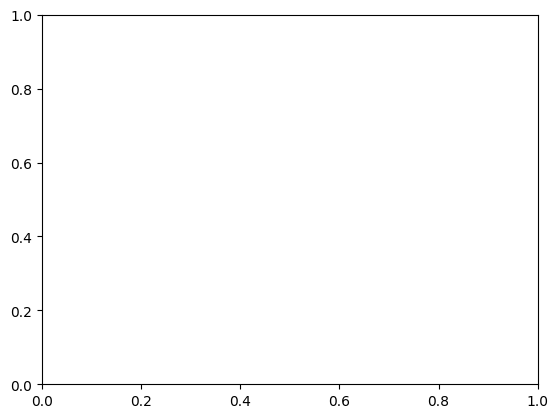

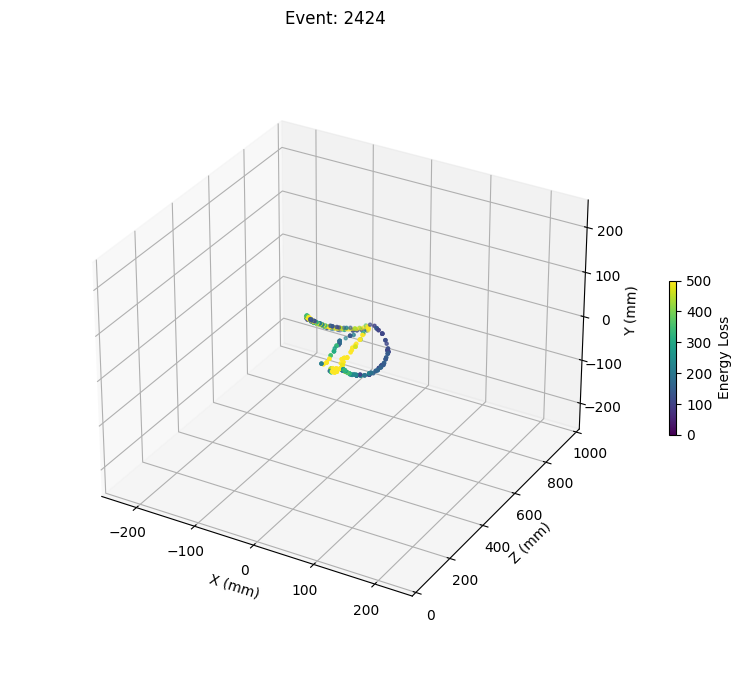

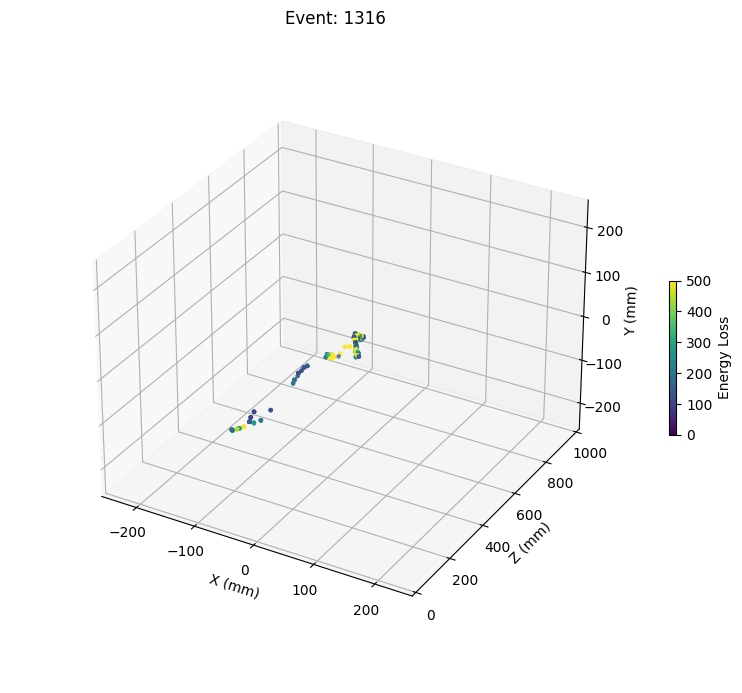

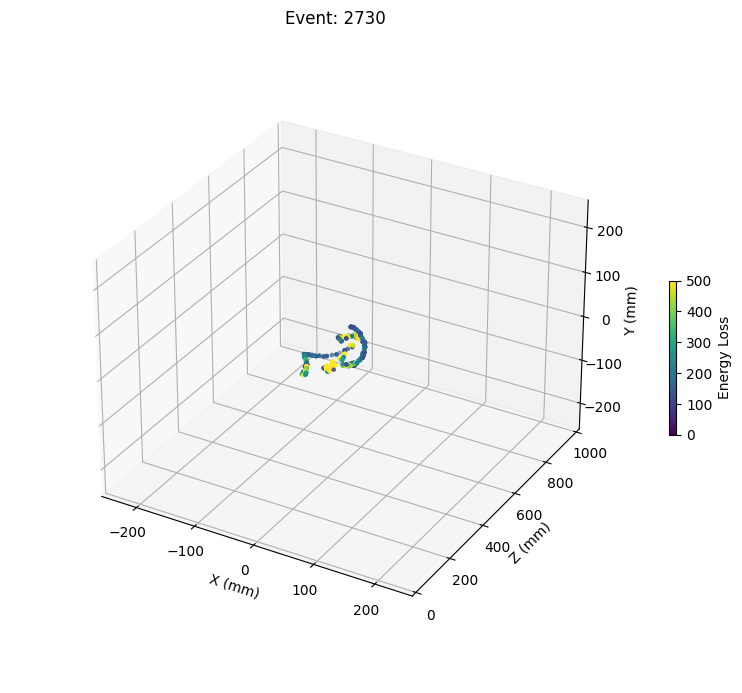

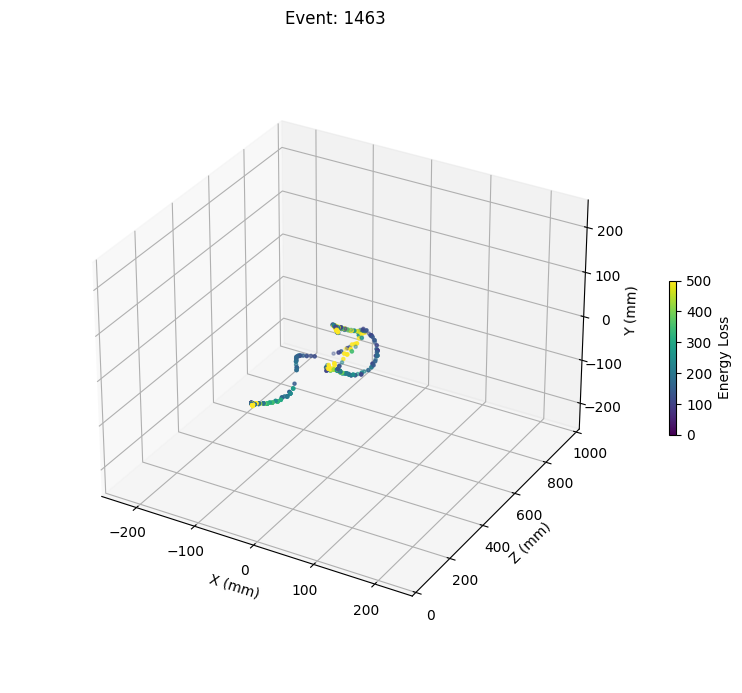

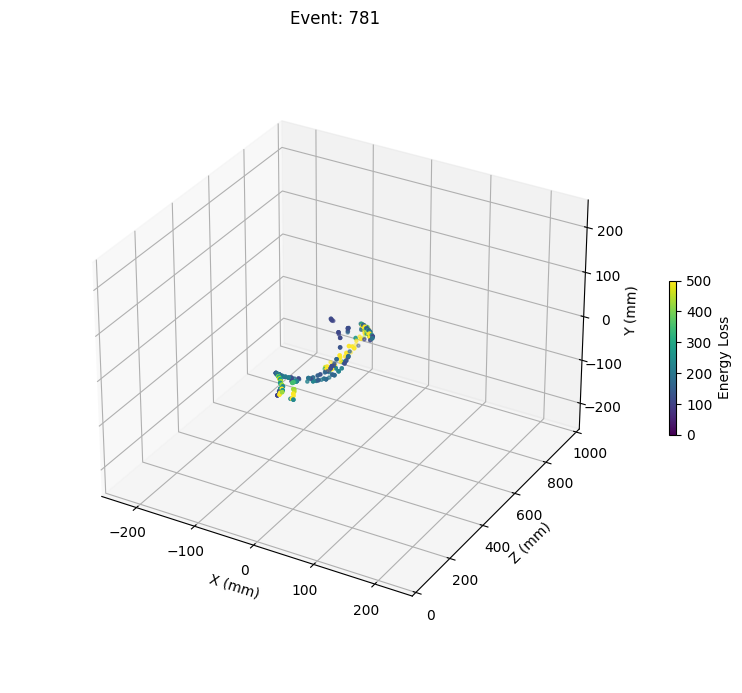

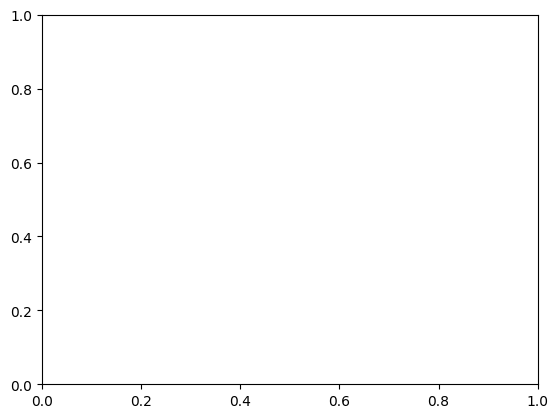

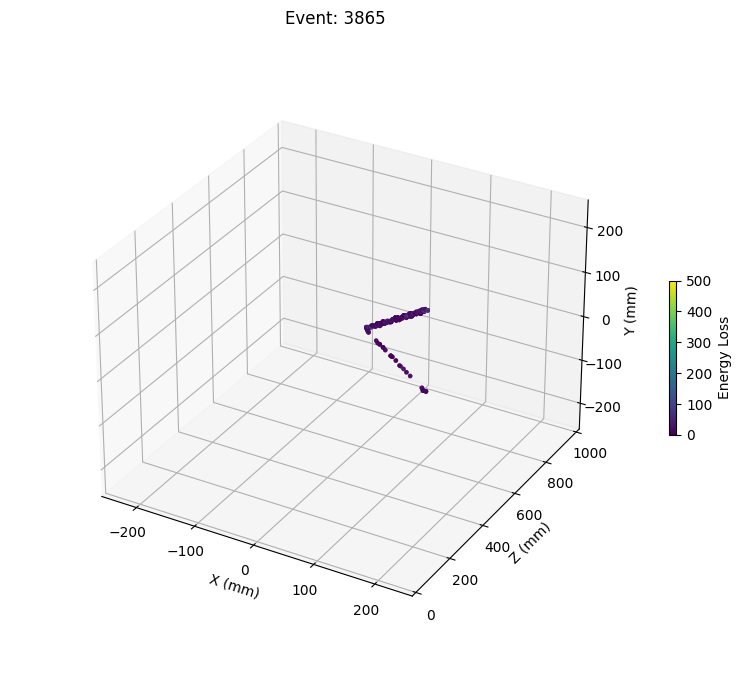

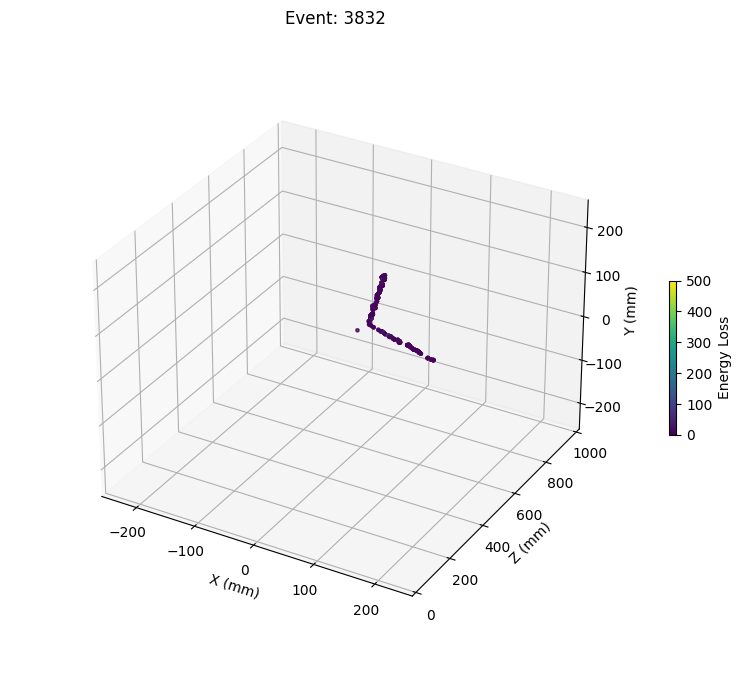

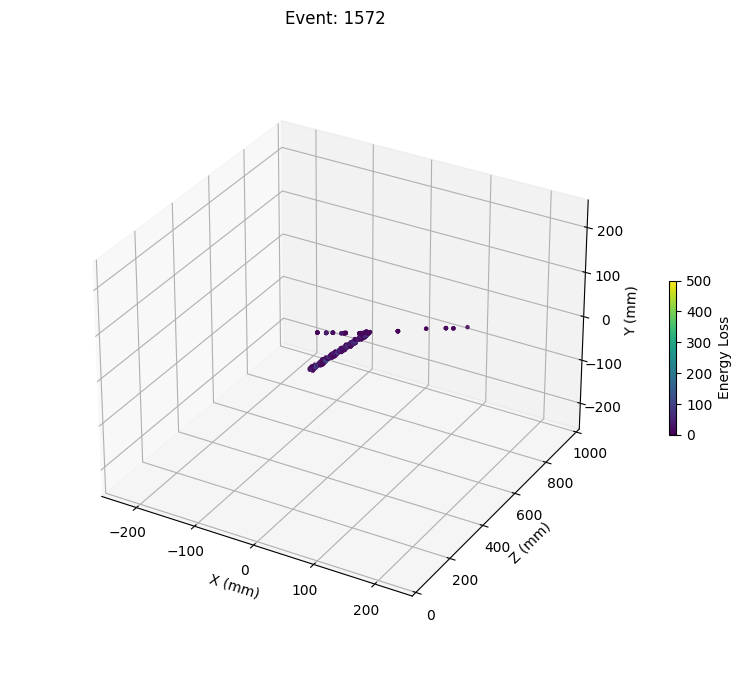

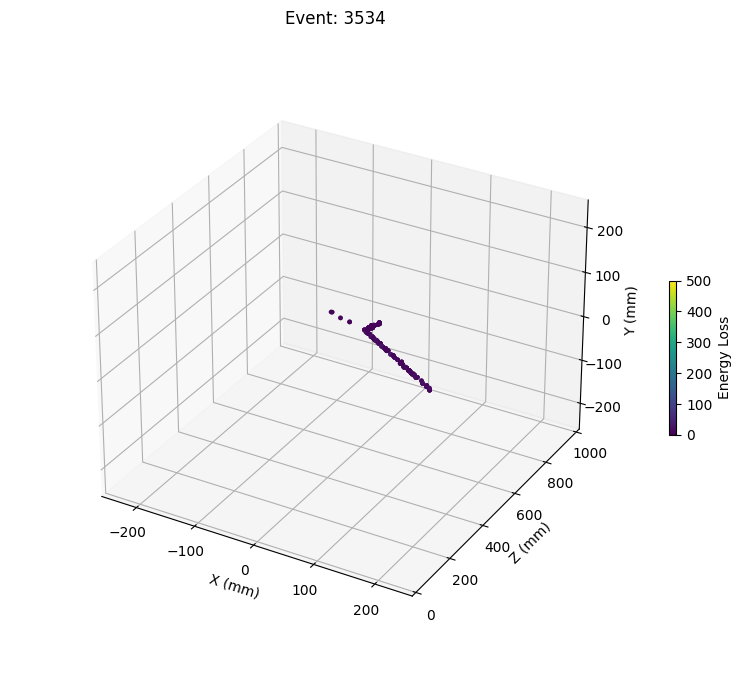

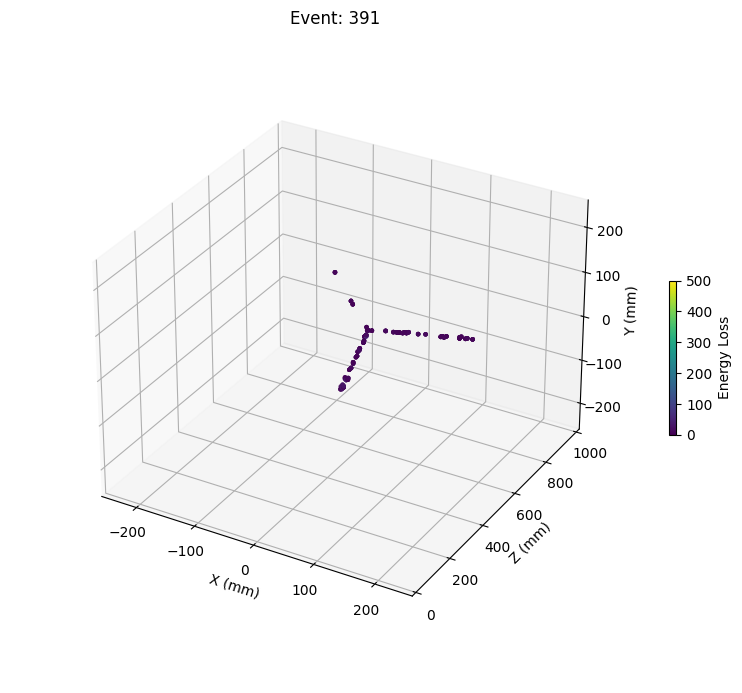

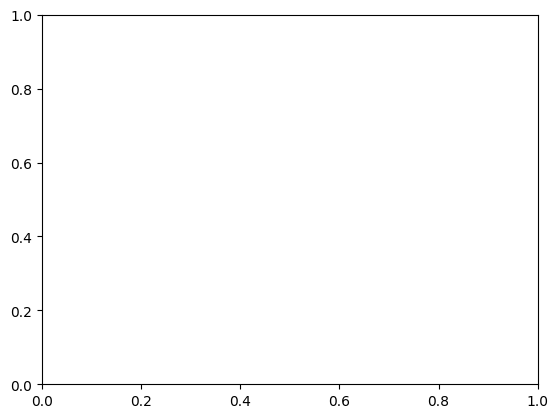

In [ ]:
#load clustered data
umap_Mg22 = np.load('./plots/umap/2d_plots/umap_data/Mg22_Simulated_n200.npy')
umap_3track = np.load('./plots/umap/2d_plots/umap_data/O16_3track_n200.npy')
umap_2track = np.load('./plots/umap/2d_plots/umap_data/O16_2track_n200.npy')

#plot events plot_umap_events(clustering_data, label, extracted_simulated_data)
plot_umap_events(umap_Mg22, 'Mg22_Simulated', '../simulated_data/process_data/Mg22/voxel_data/output_digi_HDF_Mg22_Ne20pp_8MeV/Mg22_size512')
plot_umap_events(umap_3track, '3_track', '../simulated_data/process_data/O16/voxel_data/output_digi_HDF_3Body/O16_size512')
plot_umap_events(umap_2track, '2_track', '../simulated_data/process_data/O16/voxel_data/output_digi_HDF_2Body/O16_size512')